In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.interpolate import make_interp_spline, BSpline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_error, r2_score

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['text.usetex'] = True
warnings.filterwarnings(action="ignore")

In [2]:
df = pd.read_csv('Ratio.csv')
df.head()

,Lb/ry,h/tw,B/2t,h/B,tf/tw,E/Fy,Mp/Mcr,Mn/Mp
0,45.845272,41.0,4.491525,2.655975,1.718447,208.279468,0.558946,0.843663
1,54.441261,41.0,4.491525,2.655975,1.718447,208.279468,0.789461,0.760744
2,65.902579,41.0,4.491525,2.655975,1.718447,208.279468,0.978898,0.647926
3,74.498567,41.0,4.491525,2.655975,1.718447,208.279468,1.248814,0.570788
4,85.959885,41.0,4.491525,2.655975,1.718447,208.279468,1.607064,0.483207


In [3]:
X_full = df[['Lb/ry', 'h/tw', 'B/2t', 'h/B', 'tf/tw', 'E/Fy', 'Mp/Mcr']]
y_full = df['Mn/Mp']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=123)

In [4]:
standard_scalar = StandardScaler()
X_train_transformed = standard_scalar.fit_transform(X_train)
X_full_transformed = standard_scalar.transform(X_full)

In [5]:
layersize = list(range(5, 25))
lmselist = []

for x in layersize:
    mse_tests = []

    for _ in range(128):
        mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), solver='lbfgs', early_stopping=False, max_iter=3000, n_iter_no_change=3000)
        mlp.fit(X_train_transformed, y_train)
        y_predict = mlp.predict(X_full_transformed)
        mse_test = mean_squared_error(y_predict, y_full)
        mse_tests.append(mse_test)
    
    lmselist.append(np.min(mse_test))

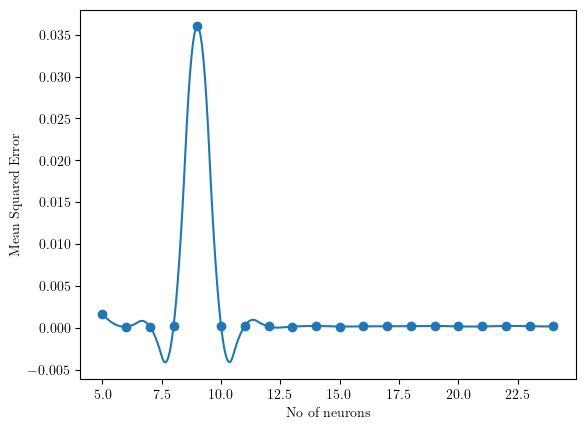

In [13]:
layersize_new = np.linspace(np.min(layersize), np.max(layersize), 300)
spl = make_interp_spline(layersize, lmselist, k=2)  # type: BSpline
lmselist_new = spl(layersize_new)

plt.plot(layersize_new, lmselist_new)
plt.scatter(layersize, lmselist)
plt.ylabel("Mean Squared Error")
plt.xlabel("No of neurons")
plt.savefig(f'MLP/mse-neurons.png', dpi=640, bbox_inches='tight')
# plt.xlim([8, 25])
# plt.ylim([0, 0.001])
plt.show()

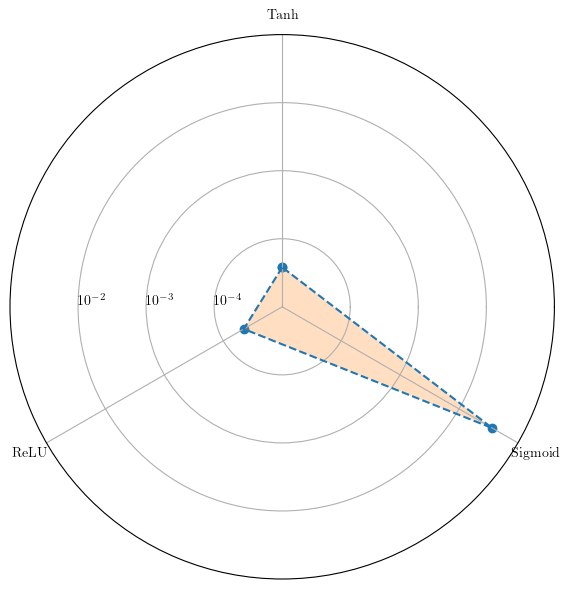

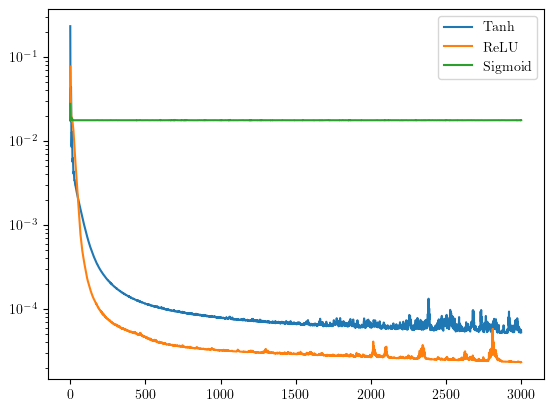

In [23]:
activations = ['tanh', 'relu', 'logistic']
mselist = []
loss_curves = []

for af in activations:
    x = 20
    mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), activation=af, random_state=100, early_stopping=True, max_iter=3000, n_iter_no_change=3000)
    mlp.fit(X_train_transformed, y_train)

    y_predict = mlp.predict(X_full_transformed)

    loss_curves.append(mlp.loss_curve_)

    mse_test = mean_squared_error(y_predict, y_full)
    
    mselist.append(mse_test)

mselist = np.log10(mselist)
num_vars = len(activations)

# Compute angle for each axis, rotated so first (LBFGS) is on top
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = [a + np.pi / 2 for a in angles]  # Rotate 90 degrees to start at top
mselist = np.concatenate((mselist, [mselist[0]]))  # Close the loop
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.scatter(angles, mselist)
ax.plot(angles, mselist, '--')
ax.fill(angles, mselist, alpha=0.25)

# Customize labels and ticks
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Tanh", "ReLU", "Sigmoid"])
ax.set_rlabel_position(180)
ax.set_yticks([-4, -3, -2])  # Log10 ticks
ax.set_yticklabels(["$10^{-4}$", "$10^{-3}$", "$10^{-2}$"])
ax.set_ylim(-5, -1)

plt.tight_layout()
plt.savefig(f'MLP/mse-activation.png', dpi=640, bbox_inches='tight')
plt.show()


for af, loss in zip(activations, loss_curves):
    if af == 'tanh':
        af = 'Tanh'
    elif af == 'relu':
        af = 'ReLU'
    else:
        af = 'Sigmoid'
    plt.semilogy(range(len(loss)), loss, label=af)
plt.legend()
# plt.show()
plt.savefig(f'MLP/loss-activation', dpi=640, bbox_inches='tight')
plt.show()

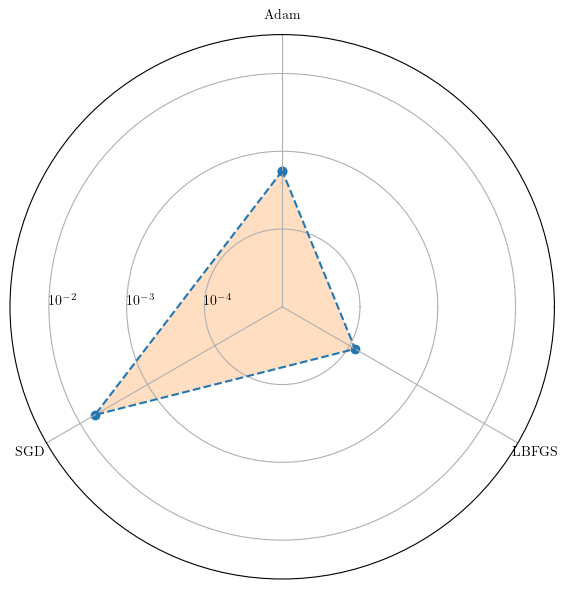

In [22]:
solvers = ['adam', 'sgd', 'lbfgs']
mselist = []
r2list = []

for slv in solvers:
    x = 20
    mlp = MLPRegressor(hidden_layer_sizes=(x,x,x,x,x,x,x), solver=slv, activation='relu', random_state=100, early_stopping=True, max_iter=1000)
    mlp.fit(X_train, y_train)

    y_predict = mlp.predict(X_full)

    mse_test = mean_squared_error(y_predict, y_full)
    r2_test = r2_score(y_predict, y_full)
    
    mselist.append(mse_test)
    r2list.append(r2_test)

mselist = np.log10(mselist)
num_vars = len(solvers)

# Compute angle for each axis, rotated so first (LBFGS) is on top
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles = [a + np.pi / 2 for a in angles]  # Rotate 90 degrees to start at top
mselist = np.concatenate((mselist, [mselist[0]]))  # Close the loop
angles += angles[:1]

# Create radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, mselist, '--')
ax.scatter(angles, mselist)
ax.fill(angles, mselist, alpha=0.25)

# Customize labels and ticks
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Adam", "SGD", "LBFGS"])
ax.set_rlabel_position(180)
ax.set_yticks([-4, -3, -2])  # Log10 ticks
ax.set_yticklabels(["$10^{-4}$", "$10^{-3}$", "$10^{-2}$"])
ax.set_ylim(-5, -1.5)

plt.tight_layout()
plt.savefig(f'MLP/mse-solver.png', dpi=640, bbox_inches='tight')
plt.show()

# plt.bar(solvers, mselist)
# plt.ylabel("MSE")
# plt.xlabel("Optimizer")
# # plt.show()
# plt.savefig(f'MLP/mse-activation.png', dpi=640, bbox_inches='tight')
# plt.show()

# plt.ylim([-0.1, 1])
# plt.bar(solvers, r2list)
# plt.ylabel(r"$R^2$ Score")
# plt.xlabel(r"Optimizer")
# # plt.show()
# plt.savefig(f'MLP/r2-activation.png', dpi=640, bbox_inches='tight')
# plt.show()